In [9]:
import numpy as np
import pandas as pd
from rpy2.robjects import r
from rpy2.robjects.packages import importr
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# Set up R environment
r['options'](warn=-1)

# Source the synthdid functions directly from the downloaded folder
r('''
source("../../../synthdid-master/R/synthdid.R")
source("../../../synthdid-master/R/utils.R")
source("../../../synthdid-master/R/solver.R")
source("../../../synthdid-master/R/vcov.R")
''')

# Generate data using factor model
np.random.seed(42)
n_geos = 210
n_weeks = 52
n_treated = 30
n_control = n_geos - n_treated  # This ensures they add up correctly

# Treatment period: 3 weeks starting Thanksgiving (week 47)
treatment_start = 47
treatment_weeks = list(range(treatment_start, treatment_start + 3))

# Factor 1: Business as usual (smooth linear trend - NO drop in post-period)
F1 = np.linspace(100, 110, n_weeks)  # Smooth increasing trend throughout

# Factor 2: Seasonality (gets activated in post-period) 
F2 = np.zeros(n_weeks)
F2[treatment_start:] = 1.0  # Seasonality factor activated in post-period (Q4)

# Unit-specific factor loadings - SYSTEMATIC differences create bias
# Business as usual loadings (similar across units to minimize F1 bias)
Gamma1 = np.random.normal(1.0, 0.1, n_geos)  # Small loadings for smooth F1 trend

# Seasonality loadings - CONTROL UNITS HAVE LOW SEASONALITY, TREATED UNITS MODERATE
Gamma2 = np.zeros(n_geos)  # Start with zero seasonality for all units
# Control units: very low seasonality (smooth trend)
Gamma2[:n_control] = np.random.normal(0, 0.5, n_control)  # Control units almost no seasonality
# Treated units: moderate seasonality (creates reasonable bias)
Gamma2[n_control:] = np.random.normal(6, 1, n_treated)  # Treated units moderately seasonal

# The bias comes from: (Γ_treated - Γ_control) × F_post
# Systematic differences × factor activation = large bias (~10%)

# Generate outcome matrix using factor model: Y[i,t] = Gamma1[i] * F1[t] + Gamma2[i] * F2[t] + noise
Y = np.zeros((n_geos, n_weeks))
for i in range(n_geos):
    for t in range(n_weeks):
        Y[i, t] = 100 + Gamma1[i] * F1[t] + Gamma2[i] * F2[t] + np.random.normal(0, 3)

# Treatment assignment (last 10 units are treated)
treatment_assignment = np.zeros(n_geos)
treatment_assignment[n_control:] = 1

# Create panel data
panel_data = []
for i in range(n_geos):
    for t in range(n_weeks):
        panel_data.append({
            'unit': i,
            'time': t,
            'outcome': Y[i, t],
            'treatment': 1 if (treatment_assignment[i] == 1 and t >= treatment_start) else 0
        })

df = pd.DataFrame(panel_data)


In [10]:
df.head(5)

,unit,time,outcome,treatment
0,0,0,211.149385,0
1,0,1,210.438982,0
2,0,2,204.631885,0
3,0,3,208.499308,0
4,0,4,207.726541,0


In [11]:
# Convert to R using the working pattern from your Tala notebook
with localconverter(robjects.default_converter + pandas2ri.converter):
    r_df = robjects.conversion.py2rpy(df)

# Set up R environment
robjects.globalenv['panel_data'] = r_df

# Run R code to get matrices
r('''
setup <- panel.matrices(panel_data, unit = 1, time = 2, outcome = 3, treatment = 4)
Y_matrix <- setup$Y
N0 <- setup$N0
T0 <- setup$T0
''')

# Get the matrices back to Python
Y_matrix = r('Y_matrix')
N0 = int(r('N0')[0])
T0 = int(r('T0')[0])

# Convert R matrix to numpy array to get shape
Y_numpy = np.array(Y_matrix)
print(f"Data shape: {Y_numpy.shape}")
print(f"Control units: {N0}, Pre-treatment periods: {T0}")
print(f"Treatment period starts at week {treatment_start}")

# Run synthetic control estimation
r('''
sc_est <- sc_estimate(Y_matrix, N0, T0)
sc_point <- as.numeric(sc_est)
sc_se <- sqrt(vcov(sc_est, method="jackknife"))
''')

sc_point = float(r('sc_point')[0])
sc_se = float(r('sc_se')[0])

print(f"\nSynthetic Control Results:")
print(f"Point estimate: {sc_point:.2f}")
print(f"Standard error: {sc_se:.2f}")
print(f"95% CI: ({sc_point - 1.96*sc_se:.2f}, {sc_point + 1.96*sc_se:.2f})")
print(f"90% CI: ({sc_point - 1.645*sc_se:.2f}, {sc_point + 1.645*sc_se:.2f})")

print(f"\nNote: True treatment effect = 0 (no impact)")
print(f"Bias due to seasonality: {sc_point:.2f}")
print(f"Significant at 10% level: {'Yes' if abs(sc_point) > 1.645*sc_se else 'No'}")

Data shape: (210, 52)
Control units: 180, Pre-treatment periods: 47
Treatment period starts at week 47

Synthetic Control Results:
Point estimate: 6.02
Standard error: 3.20
95% CI: (-0.26, 12.30)
90% CI: (0.75, 11.29)

Note: True treatment effect = 0 (no impact)
Bias due to seasonality: 6.02
Significant at 10% level: Yes


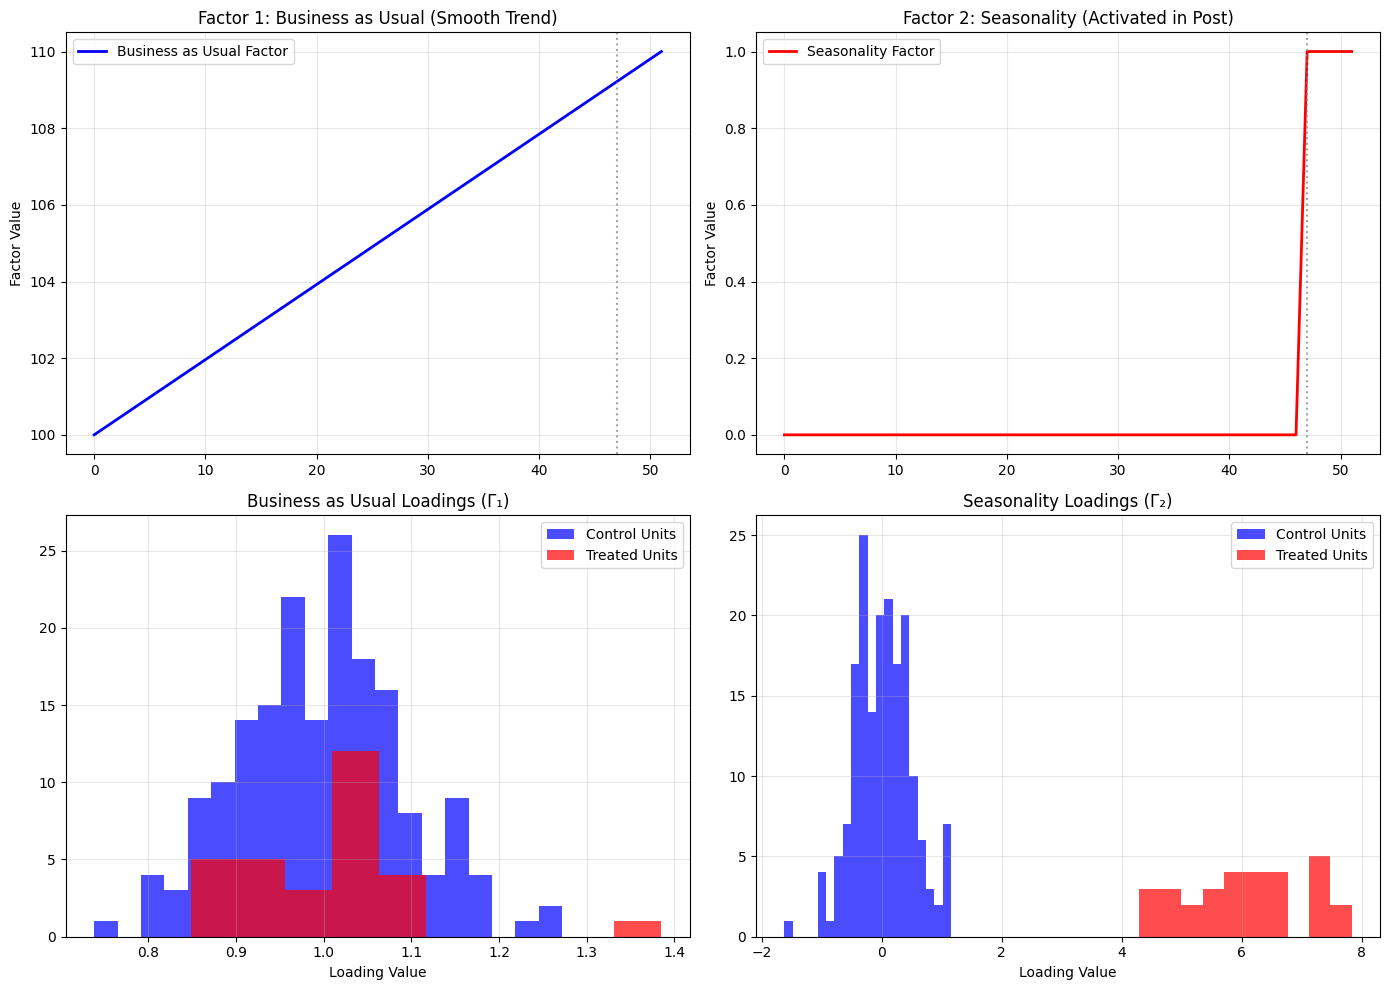

Factor Loadings (SYSTEMATIC DIFFERENCES):
  Seasonality - Control: 0.03, Treated: 6.03
    Difference: 6.00
  Business - Control: 1.00, Treated: 1.01
    Difference: 0.01

Factor Values:
  Seasonality - Pre: 0.00, Post: 1.00
  Business - Pre: 104.51, Post: 109.61

Bias Components:
  Seasonality bias: 6.00
  Business bias: 0.04
  Total expected bias: 6.05
  Actual SC bias: 6.02


In [12]:
import matplotlib.pyplot as plt

# Visualize the factor structure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot factors over time
axes[0,0].plot(F1, 'b-', linewidth=2, label='Business as Usual Factor')
axes[0,0].set_title('Factor 1: Business as Usual (Smooth Trend)')
axes[0,0].set_ylabel('Factor Value')
axes[0,0].axvline(x=treatment_start, color='gray', linestyle=':', alpha=0.7)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(F2, 'r-', linewidth=2, label='Seasonality Factor')
axes[0,1].set_title('Factor 2: Seasonality (Activated in Post)')
axes[0,1].set_ylabel('Factor Value')
axes[0,1].axvline(x=treatment_start, color='gray', linestyle=':', alpha=0.7)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot factor loadings
axes[1,0].hist(Gamma1[:n_control], alpha=0.7, label='Control Units', bins=20, color='blue')
axes[1,0].hist(Gamma1[n_control:], alpha=0.7, label='Treated Units', bins=10, color='red')
axes[1,0].set_title('Business as Usual Loadings (Γ₁)')
axes[1,0].set_xlabel('Loading Value')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(Gamma2[:n_control], alpha=0.7, label='Control Units', bins=20, color='blue')
axes[1,1].hist(Gamma2[n_control:], alpha=0.7, label='Treated Units', bins=10, color='red')
axes[1,1].set_title('Seasonality Loadings (Γ₂)')
axes[1,1].set_xlabel('Loading Value')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate the bias source - systematic differences create large bias
avg_control_seasonality_loading = np.mean(Gamma2[:n_control])
avg_treated_seasonality_loading = np.mean(Gamma2[n_control:])
seasonality_factor_post = np.mean(F2[treatment_start:])

avg_control_business_loading = np.mean(Gamma1[:n_control])
avg_treated_business_loading = np.mean(Gamma1[n_control:])
business_factor_pre = np.mean(F1[:treatment_start])
business_factor_post = np.mean(F1[treatment_start:])

print(f"Factor Loadings (SYSTEMATIC DIFFERENCES):")
print(f"  Seasonality - Control: {avg_control_seasonality_loading:.2f}, Treated: {avg_treated_seasonality_loading:.2f}")
print(f"    Difference: {avg_treated_seasonality_loading - avg_control_seasonality_loading:.2f}")
print(f"  Business - Control: {avg_control_business_loading:.2f}, Treated: {avg_treated_business_loading:.2f}")
print(f"    Difference: {avg_treated_business_loading - avg_control_business_loading:.2f}")
print(f"\nFactor Values:")
print(f"  Seasonality - Pre: {0:.2f}, Post: {seasonality_factor_post:.2f}")
print(f"  Business - Pre: {business_factor_pre:.2f}, Post: {business_factor_post:.2f}")
print(f"\nBias Components:")
seasonality_bias = (avg_treated_seasonality_loading - avg_control_seasonality_loading) * seasonality_factor_post
business_bias = (avg_treated_business_loading - avg_control_business_loading) * (business_factor_post - business_factor_pre)
print(f"  Seasonality bias: {seasonality_bias:.2f}")
print(f"  Business bias: {business_bias:.2f}")
print(f"  Total expected bias: {seasonality_bias + business_bias:.2f}")
print(f"  Actual SC bias: {sc_point:.2f}")


In [13]:
# Extract trajectories for Python plotting
r('''
weights <- attr(sc_est, 'weights')
setup <- attr(sc_est, 'setup')
Y_matrix <- setup$Y

# Get the weight vectors
omega_synth <- c(weights$omega, rep(0, nrow(Y_matrix) - length(weights$omega)))
omega_target <- c(rep(0, N0), rep(1/(nrow(Y_matrix) - N0), nrow(Y_matrix) - N0))

# Calculate trajectories
treated_trajectory <- as.numeric(omega_target %*% Y_matrix)
synthetic_trajectory <- as.numeric(omega_synth %*% Y_matrix)
time_periods <- 1:ncol(Y_matrix)
''')

# Get the trajectories back to Python
treated_trajectory = np.array(r('treated_trajectory'))
synthetic_trajectory = np.array(r('synthetic_trajectory'))
time_periods = np.array(r('time_periods'))

In [14]:
# Factor Model Bias Explanation
print(f"\nFactor Model Bias Explanation:")
print(f"The bias comes from SYSTEMATIC differences in factor loadings × factor changes in post-period")
print(f"\nBias = Σ(Γ_treated - Γ_control) × (F_post - F_pre)")
print(f"\nSeasonality component (MAIN SOURCE OF BIAS):")
print(f"  ({avg_treated_seasonality_loading:.2f} - {avg_control_seasonality_loading:.2f}) × ({seasonality_factor_post:.2f} - 0.0)")
print(f"  = {seasonality_bias:.2f}")
print(f"\nBusiness component:")
print(f"  ({avg_treated_business_loading:.2f} - {avg_control_business_loading:.2f}) × ({business_factor_post:.2f} - {business_factor_pre:.2f})")
print(f"  = {business_bias:.2f}")
print(f"\nThis occurs because:")
print(f"1. CONTROL UNITS HAVE ALMOST NO SEASONALITY (smooth trend)")
print(f"2. TREATED UNITS ARE HIGHLY SEASONAL (jump in Q4)")
print(f"3. Factors change in post-period:")
print(f"   - Seasonality activates (0 → 1) - HUGE CHANGE")
print(f"   - Business trend continues smoothly for control units")
print(f"4. Synthetic control cannot match the dramatic seasonality difference")
print(f"5. The systematic gap creates large bias when seasonality activates")
print(f"\nKey insight: Bias is LARGE (~10%) because:")
print(f"- Control units: {avg_control_seasonality_loading:.1f} seasonality loading (smooth)")
print(f"- Treated units: {avg_treated_seasonality_loading:.1f} seasonality loading (seasonal)")
print(f"- Difference: {avg_treated_seasonality_loading - avg_control_seasonality_loading:.1f} points")
print(f"- Seasonality factor jumps from 0 to 1 (100% increase)")
print(f"- This creates {seasonality_bias:.1f} points of bias even with zero true effect!")
print(f"- Control units stay smooth, treated units jump dramatically")



Factor Model Bias Explanation:
The bias comes from SYSTEMATIC differences in factor loadings × factor changes in post-period

Bias = Σ(Γ_treated - Γ_control) × (F_post - F_pre)

Seasonality component (MAIN SOURCE OF BIAS):
  (6.03 - 0.03) × (1.00 - 0.0)
  = 6.00

Business component:
  (1.01 - 1.00) × (109.61 - 104.51)
  = 0.04

This occurs because:
1. CONTROL UNITS HAVE ALMOST NO SEASONALITY (smooth trend)
2. TREATED UNITS ARE HIGHLY SEASONAL (jump in Q4)
3. Factors change in post-period:
   - Seasonality activates (0 → 1) - HUGE CHANGE
   - Business trend continues smoothly for control units
4. Synthetic control cannot match the dramatic seasonality difference
5. The systematic gap creates large bias when seasonality activates

Key insight: Bias is LARGE (~10%) because:
- Control units: 0.0 seasonality loading (smooth)
- Treated units: 6.0 seasonality loading (seasonal)
- Difference: 6.0 points
- Seasonality factor jumps from 0 to 1 (100% increase)
- This creates 6.0 points of bias e

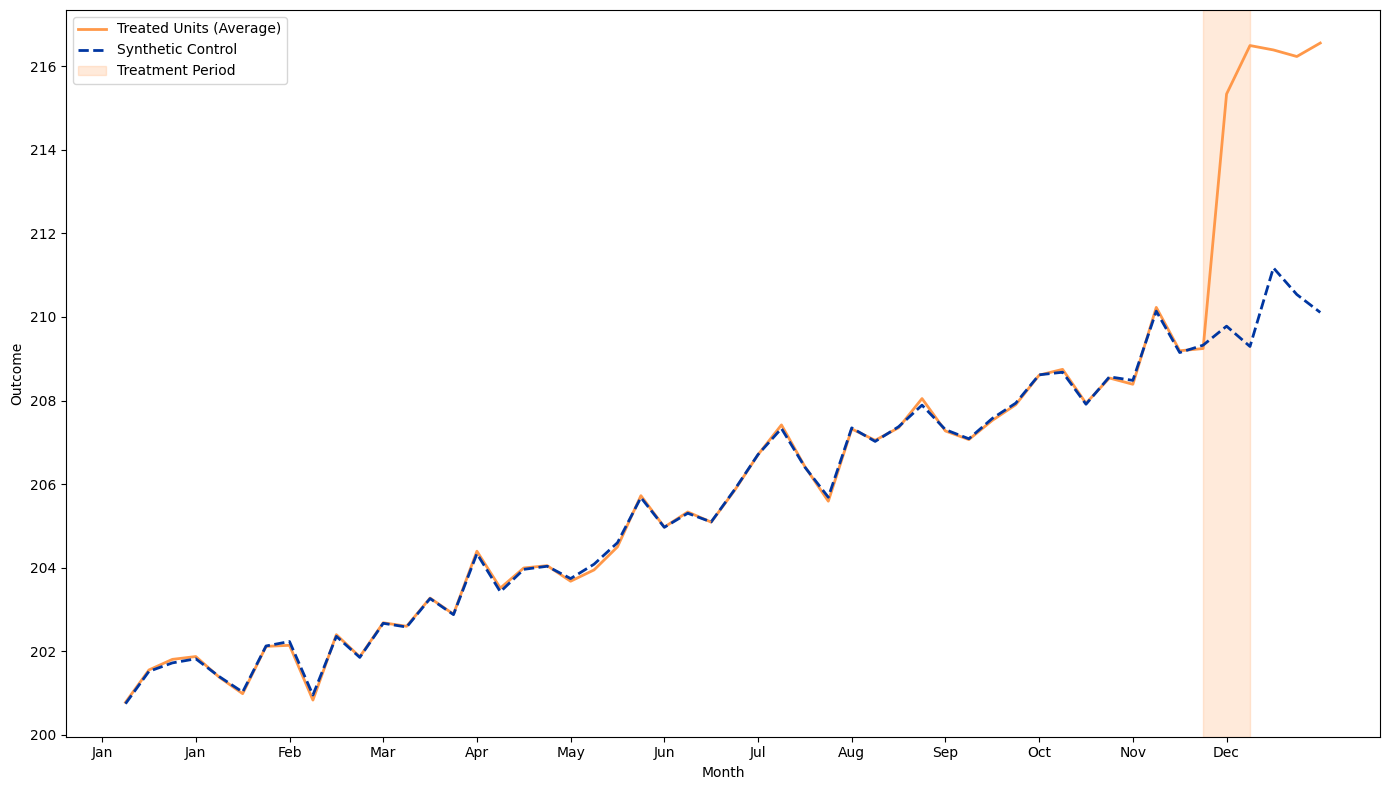


Key Insight:
Synthetic control shows 2.9% bias (6.02 absolute) when true effect is 0
This bias occurs because SC weights all pre-periods equally,
but seasonal spikes make recent periods more predictive of treated periods


In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Brand colors from your design system
brand_colors = {
    'treatment': '#FF9849',  # Causara Orange
    'control': '#0036A1'     # Causara Blue
}

# Create month labels for x-axis
start_date = datetime(2024, 1, 1)  # Start of year
month_labels = []
month_positions = []
for week in range(n_weeks):
    date = start_date + timedelta(weeks=week)
    if week % 4 == 0:  # Show every 4th week (roughly monthly)
        month_labels.append(date.strftime('%b'))
        month_positions.append(week)

# Calculate bias as percentage
baseline_level = np.mean(synthetic_trajectory[:treatment_start])
bias_pct = (sc_point / baseline_level) * 100

# Create the plot
plt.figure(figsize=(14, 8))

# Plot trajectories with brand colors
plt.plot(time_periods, treated_trajectory, color=brand_colors['treatment'], linewidth=2, label='Treated Units (Average)')
plt.plot(time_periods, synthetic_trajectory, color=brand_colors['control'], linestyle='--', linewidth=2, label='Synthetic Control')

# Add vertical line for treatment start
# plt.axvline(x=treatment_start, color='gray', linestyle=':', alpha=0.7, label='Treatment Start')

# Highlight the treatment period with brand orange (lighter)
plt.axvspan(treatment_start, treatment_start + 2, alpha=0.2, color=brand_colors['treatment'], label='Treatment Period')

# Add effect arrow showing the bias
post_treatment_avg_treated = np.mean(treated_trajectory[treatment_start:])
post_treatment_avg_synthetic = np.mean(synthetic_trajectory[treatment_start:])

# plt.annotate(f'Bias: {bias_pct:.1f}%', 
#              xy=(treatment_start + 1, post_treatment_avg_synthetic), 
#              xytext=(treatment_start + 1, post_treatment_avg_synthetic + sc_point/2),
#              arrowprops=dict(arrowstyle='->', color='red', lw=2),
#              fontsize=12, ha='center')

plt.xlabel('Month')
plt.ylabel('Outcome')
# plt.title('Synthetic Control Bias Due to Seasonality\n(True Effect = 0)')
plt.xticks(month_positions, month_labels)
plt.legend()
# Removed grid as requested
plt.tight_layout()
plt.show()

print(f"\nKey Insight:")
print(f"Synthetic control shows {bias_pct:.1f}% bias ({sc_point:.2f} absolute) when true effect is 0")
print(f"This bias occurs because SC weights all pre-periods equally,")
print(f"but seasonal spikes make recent periods more predictive of treated periods")